## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (aggregate, export, fit_scaler, load_train,
                       merge_faults, plot_bars, plot_cv,
                       plot_means, plot_stds, run_spectra,
                       versions)

print(versions())

/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 14


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Von hier gehen die Werte als Argumente in die Funktionsaufrufe. Was
# nicht gesetzt wird, bleibt auf dem Default der jeweiligen Funktion
# (pre_fault_cutoff=21, plot_mode='linear', ncols=6, ...).
# RUNS_PER_FAULT=3 kuerzt auf drei Laeufe je Fault - ein Probelauf von
# Minuten statt Stunden.

METHOD = "ica"
SCALING_MODE = "global_mean"
DATA_DIR = "data_csv"           # Ordner mit den vier TEP-CSVs
RUNS_PER_FAULT = None           # None = alle 500 Runs je Fault

# Zahl der unabhaengigen Quellen und die FastICA-
# Abbruchkriterien. ICA_RANDOM_STATE fixiert -> deterministisch.
ICA_N = 12
ICA_MAX_ITER = 1000
ICA_TOL = 1e-3
ICA_RANDOM_STATE = 42

# ICA liefert genau ICA_N Komponenten - alle zeigen.
K_MAX = 12
K_BAR = 10


## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen in DATA_DIR liegen. Sie werden EINMAL
# gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt; die
# Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(data_dir=DATA_DIR,
                              runs_per_fault=RUNS_PER_FAULT)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(METHOD, SCALING_MODE, DATA_DIR)

  lese TEP_FaultFree_Training.csv ...


  lese TEP_Faulty_Training.csv ...


  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52


  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [4]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(df_all, METHOD, scaling_mode=SCALING_MODE,
                      scaler=scaler,
                      ica_n=ICA_N, ica_max_iter=ICA_MAX_ITER,
                      ica_tol=ICA_TOL,
                      ica_random_state=ICA_RANDOM_STATE)

per_run.head()

Berechne ICA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Berechne ICA-Spektrum pro Run:   0%|          | 1/10500 [00:00<1:13:36,  2.38it/s]

Berechne ICA-Spektrum pro Run:   0%|          | 2/10500 [00:00<1:08:29,  2.55it/s]

Berechne ICA-Spektrum pro Run:   0%|          | 3/10500 [00:01<1:22:29,  2.12it/s]

Berechne ICA-Spektrum pro Run:   0%|          | 4/10500 [00:01<1:20:29,  2.17it/s]

...

Berechne ICA-Spektrum pro Run: 100%|█████████▉| 10499/10500 [41:11<00:00,  3.71it/s]

Berechne ICA-Spektrum pro Run: 100%|██████████| 10500/10500 [41:12<00:00,  3.96it/s]

Berechne ICA-Spektrum pro Run: 100%|██████████| 10500/10500 [41:12<00:00,  4.25it/s]

Erfolgreiche Runs: 10500
Fehler          : 0
FastICA konvergiert: 2164 / 10500 (20.6 %)


,faultNumber,simulationRun,ica_1,ica_2,ica_3,ica_4,ica_5,ica_6,ica_7,ica_8,ica_9,ica_10,ica_11,ica_12,converged
0,0,1,1.806975,1.213706,0.904979,-0.744122,0.737229,-0.721022,0.691063,-0.681989,-0.569593,-0.455052,0.427684,-0.070304,0
1,0,2,1.954601,1.058924,-0.747548,-0.746861,-0.597523,-0.589048,-0.480475,0.457428,-0.450657,-0.265637,0.093642,0.075210,0
2,0,3,1.652885,-0.880172,-0.745501,-0.744524,-0.622186,0.569884,-0.561863,-0.552237,-0.541883,-0.494763,0.479495,0.426695,0
3,0,4,1.405101,0.867725,0.802548,-0.734634,0.629977,0.608504,0.573698,0.363279,-0.356340,-0.289000,-0.233840,-0.214180,0
4,0,5,1.472501,1.087039,-0.870397,-0.715081,-0.675909,0.636296,-0.603740,0.446225,-0.295223,0.131691,0.095408,-0.003579,0


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [5]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(per_run, METHOD)

agg.head()

Aggregierte ICA-Statistiken pro Fault: (21, 25)


,faultNumber,ica_1_mean,ica_1_std,ica_2_mean,ica_2_std,ica_3_mean,ica_3_std,ica_4_mean,ica_4_std,ica_5_mean,...,ica_8_mean,ica_8_std,ica_9_mean,ica_9_std,ica_10_mean,ica_10_std,ica_11_mean,ica_11_std,ica_12_mean,ica_12_std
0,0,1.371498,0.925299,0.764203,0.859291,0.445544,0.834747,0.123738,0.809159,-0.094625,...,-0.246346,0.461416,-0.169562,0.428728,-0.161065,0.356844,-0.077944,0.306718,-0.056896,0.223841
1,1,14.781174,1.186584,6.822870,0.414586,4.198185,0.847916,2.028197,0.624011,1.327193,...,-0.140109,0.554609,-0.170685,0.462590,-0.128511,0.404729,-0.118688,0.317357,-0.055209,0.240161
2,2,6.174334,0.648177,1.342842,1.340795,0.623408,1.105281,0.300541,0.927275,0.124957,...,-0.226312,0.508323,-0.164803,0.463342,-0.145843,0.396104,-0.107853,0.323151,-0.064197,0.245014
3,3,1.286399,0.975124,0.637009,0.943291,0.329660,0.892291,0.038683,0.819951,-0.158101,...,-0.230030,0.490496,-0.198356,0.436794,-0.169482,0.377915,-0.116422,0.316467,-0.079727,0.239867
4,4,1.277980,0.964580,0.650876,0.938397,0.312562,0.896259,0.052615,0.826171,-0.135040,...,-0.243537,0.493342,-0.227994,0.425726,-0.181491,0.368948,-0.111831,0.316911,-0.070887,0.237584


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

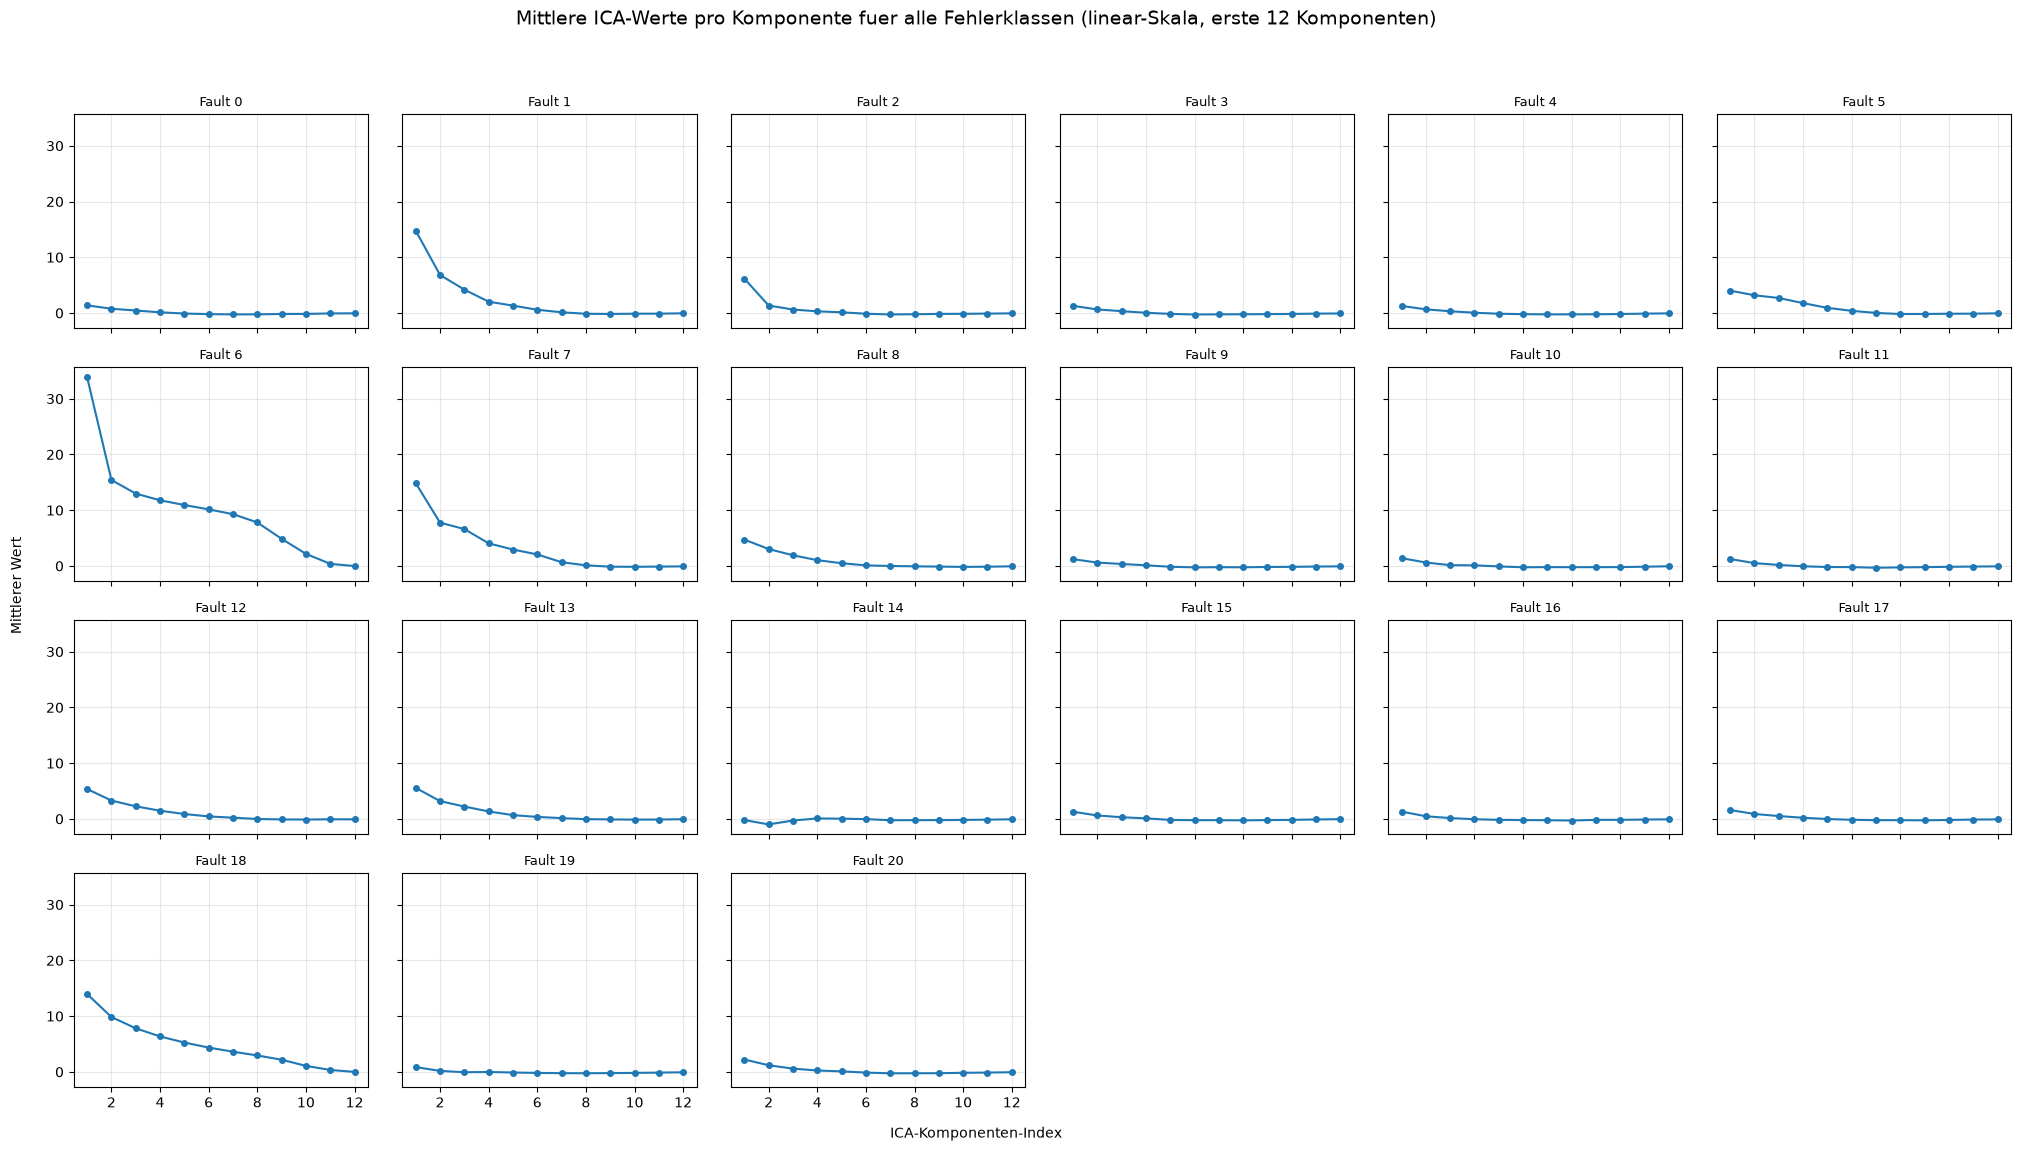

In [6]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert plot_mode
# ("linear" | "log" | "relative"), die Zahl der gezeigten Komponenten
# K_MAX.
_ = plot_means(agg, METHOD, k_max=K_MAX)

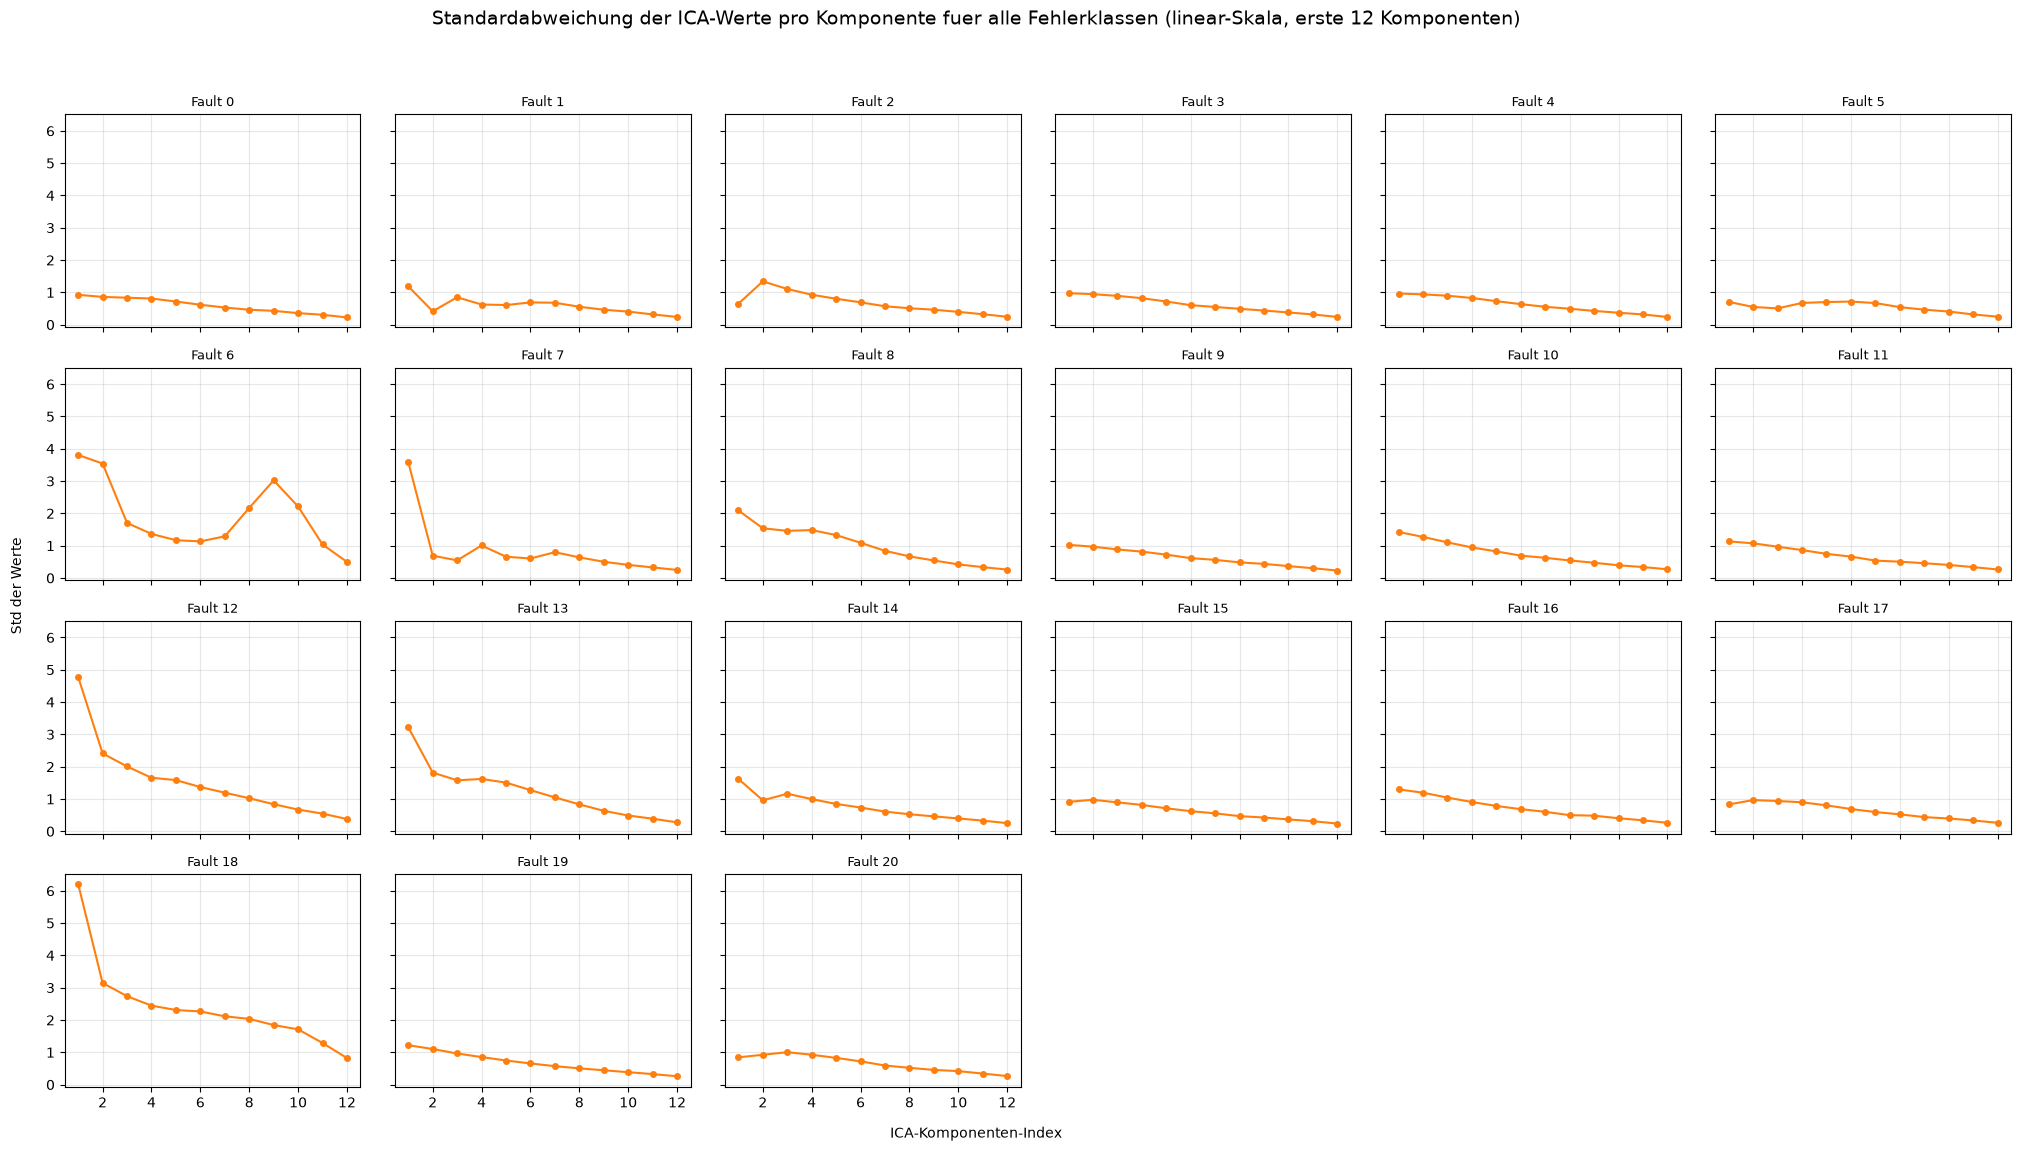

In [7]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(agg, METHOD, k_max=K_MAX)

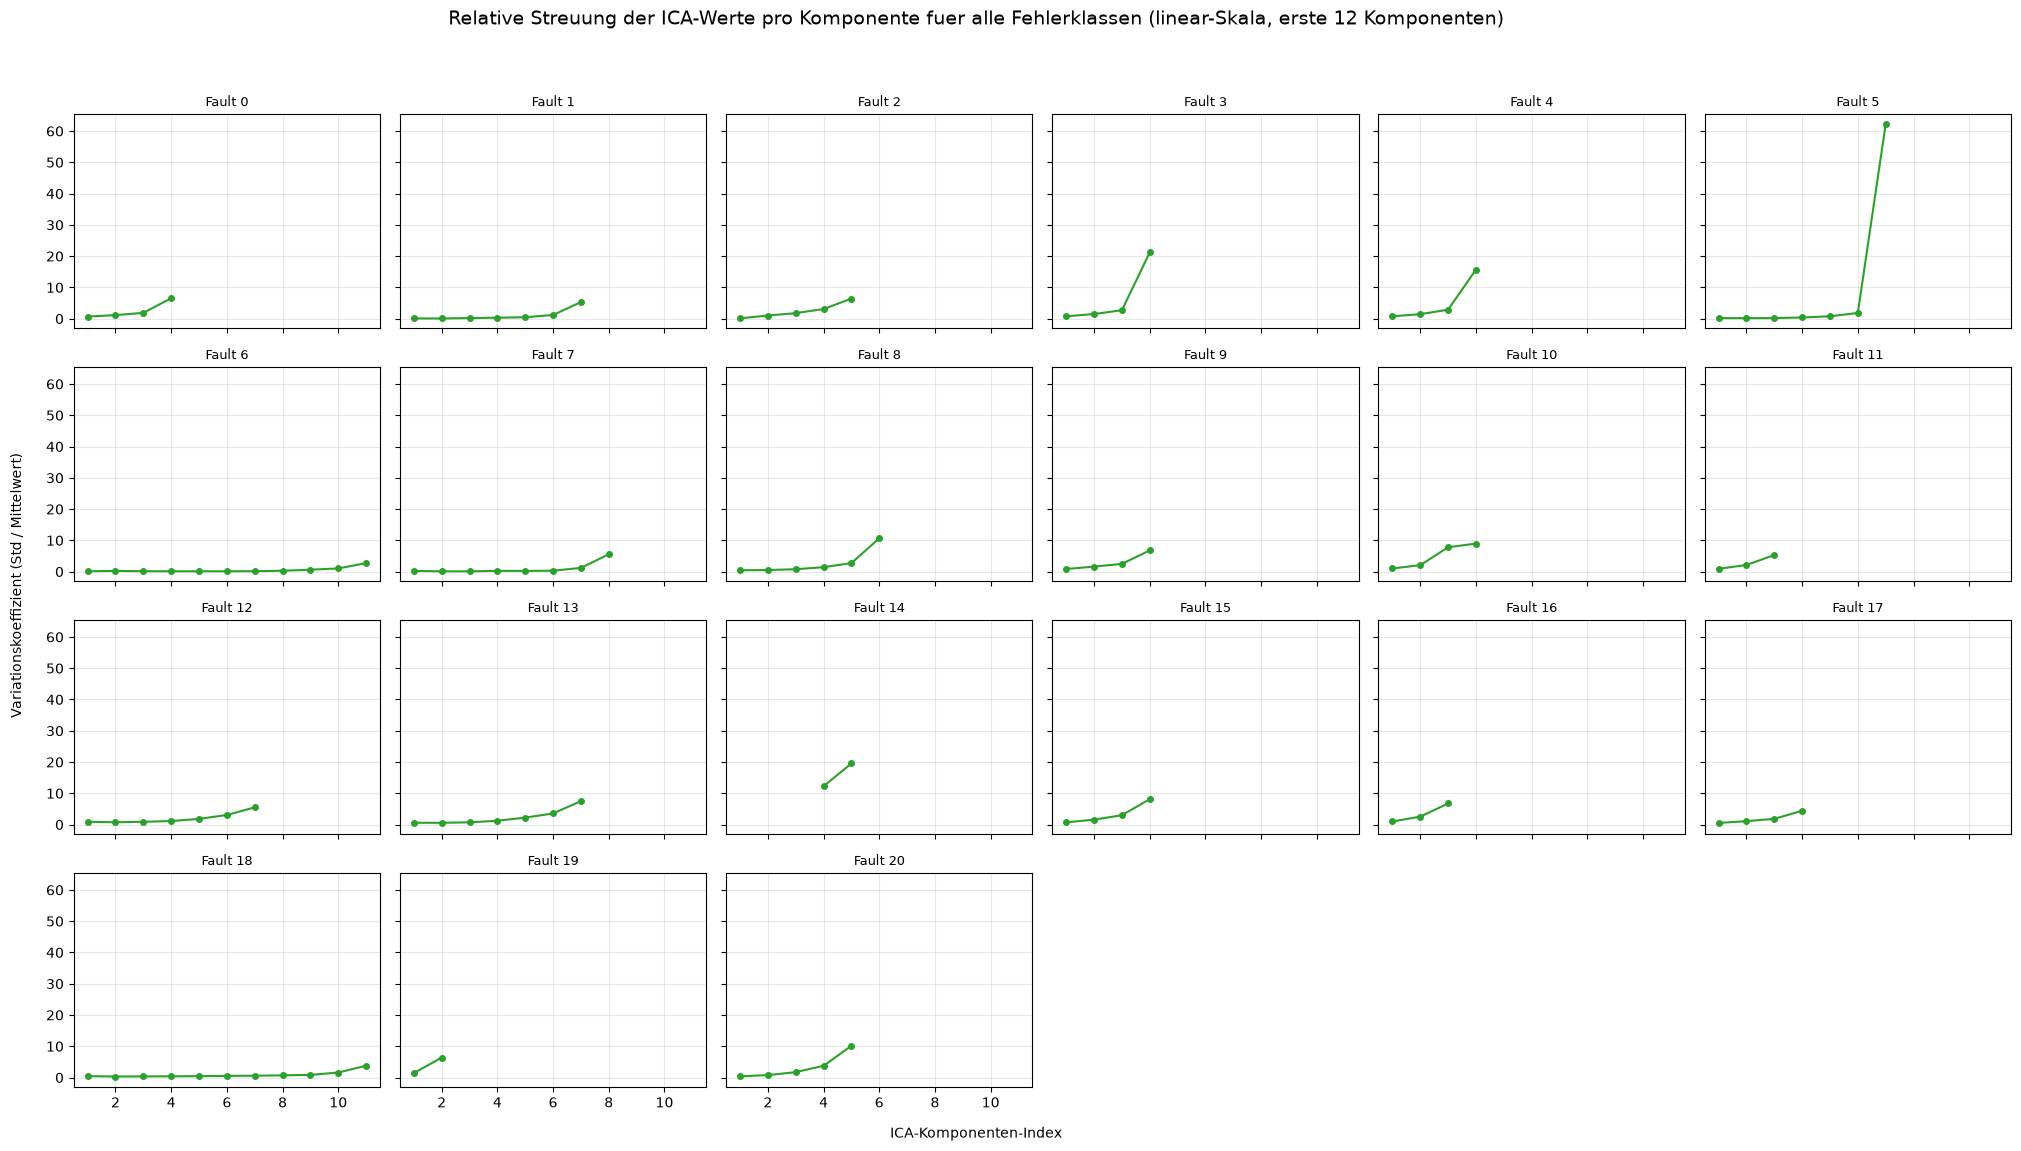

In [8]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus ueber plot_mode=... moeglich.
_ = plot_cv(agg, METHOD, k_max=K_MAX)

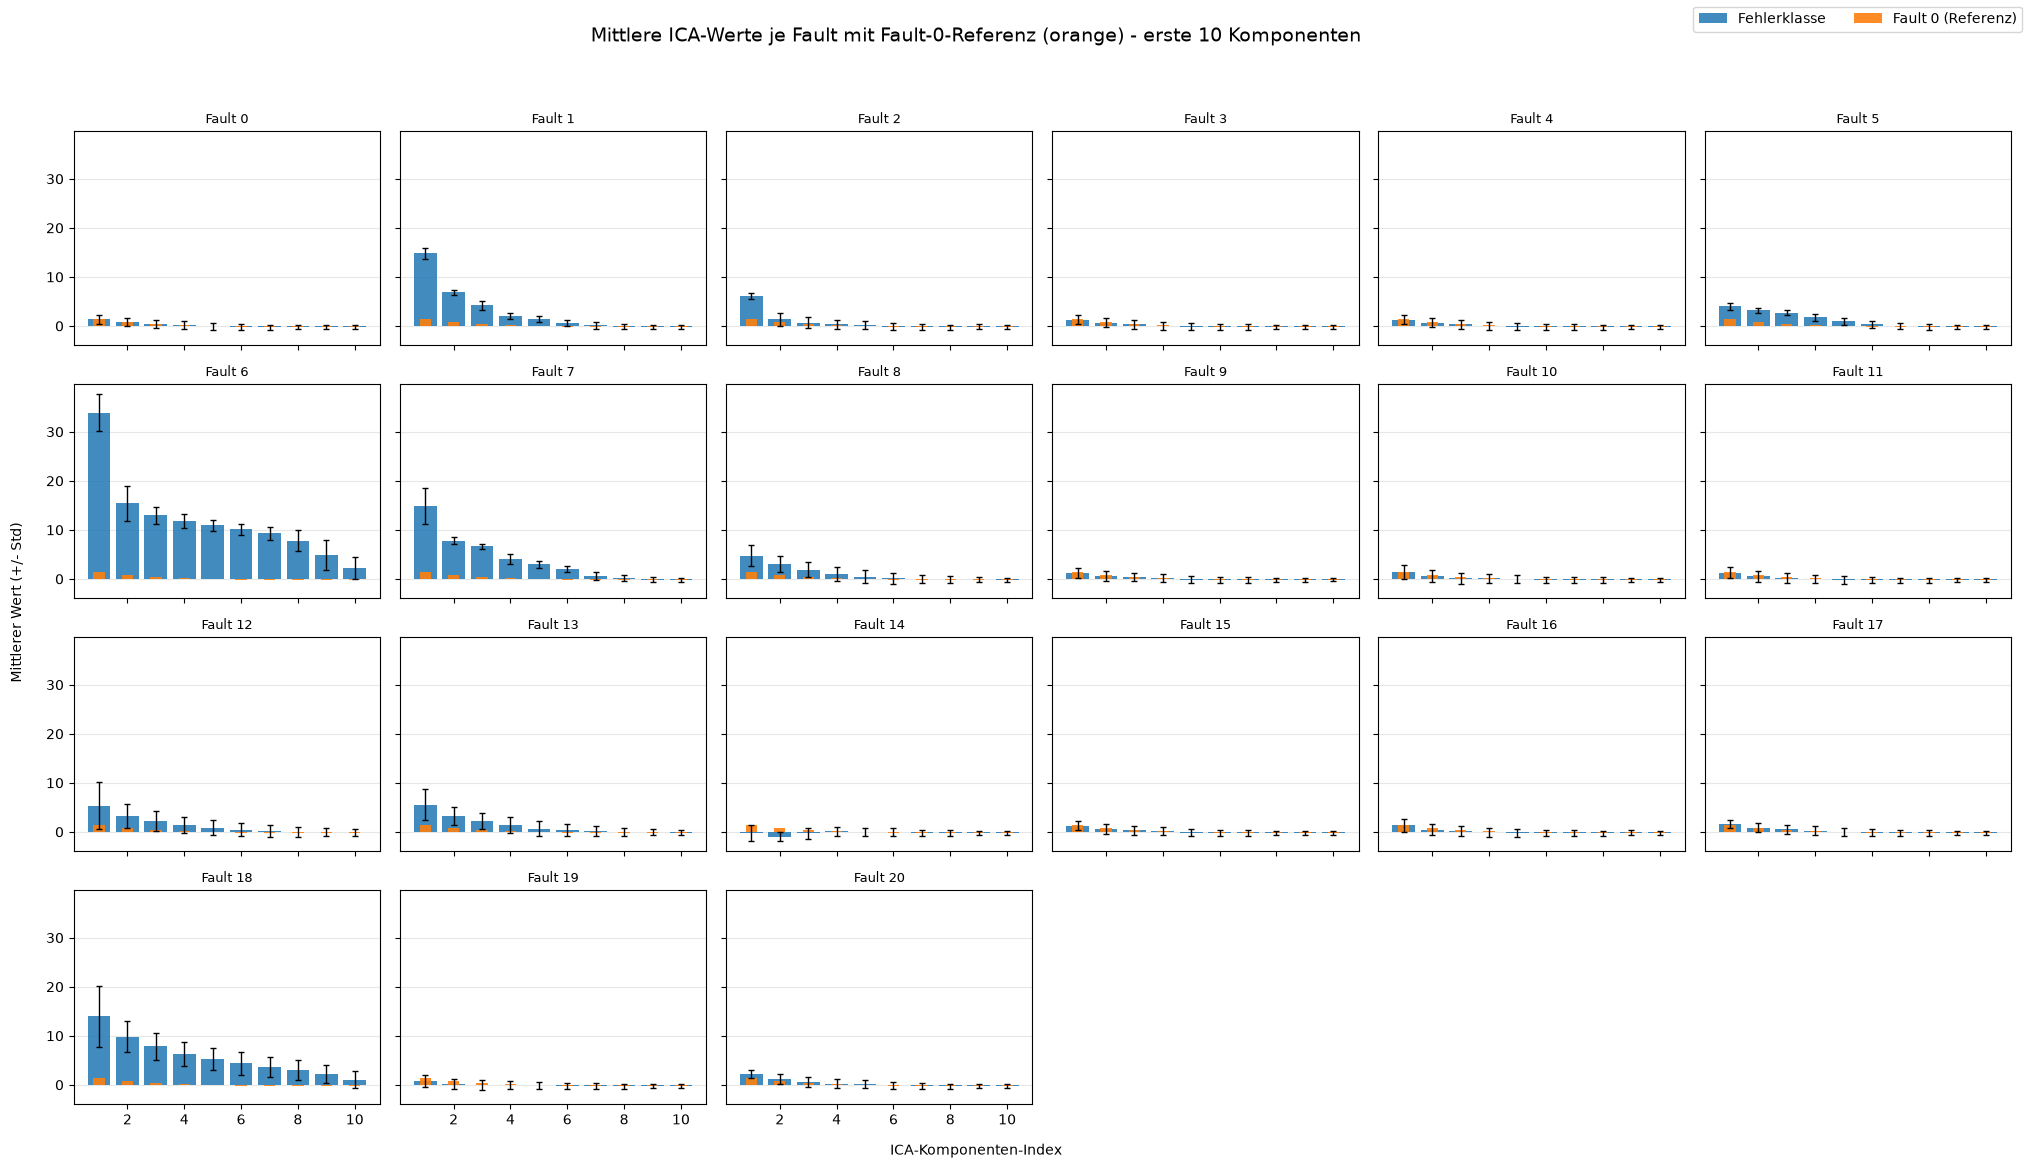

In [9]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: K_BAR.
_ = plot_bars(agg, METHOD, k_bar=K_BAR)

## Export der Trainings-Spektren

Schreibt `ica_eigenvalues_train.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [10]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(per_run, METHOD, SCALING_MODE, DATA_DIR)

ICA-Train gespeichert: (10500, 15) -> data_csv/ica_eigenvalues_train.csv


'data_csv/ica_eigenvalues_train.csv'